In [139]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import xtrack as xt
import xpart as xp

import crystal_extraction.plotters as plotters
import crystal_extraction.utils as utils
from crystal_extraction.xsuite_line_creation import create_xsuite_line
#from crystal_extraction.crystal_extraction import CrystalExtraction
from crystal_extraction.dummy_crystal import DummyCrystal
from crystal_extraction.steinbach import Steinbach, BeamArgs, SteinArgs, sps_crystal

plotters.my_mpl_style()


In [140]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

%matplotlib widget

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools

import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')

from elements import *
from optimisers import *

import elements 
import importlib
importlib.reload(elements)


<module 'elements' from '/Users/matteogiacomelli/Documents/Technical_Student/simulation/Knobs in LSS4 SPS/elements.py'>

In [141]:
line = initialise_line()

Loading line from dict:   0%|          | 0/4492 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4492 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4495 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4497 [00:00<?, ?it/s]

Non-channeled particle not lost during tracking.
The line already has an associated tracker
Channeled particle not lost during tracking.
Blocking elements encountered:
Empty DataFrame
Columns: [Position, Element Name, max_x, min_x]
Index: []


In [142]:
rematch_opticsQ22(line)

                                             
Optimize - start penalty: 63.15                             
Matching: model call n. 19 penalty = 7.1360e-08              
Optimize - end penalty:  7.136e-08                            
Target status:               nalty = 7.1360e-08              
id state tag tol_met       residue   current_val    target_val description                          
0  ON    qx     True   2.09956e-09         22.13         22.13 'qx', val=22.13, tol=1e-05, weight=10
1  ON    qy     True   6.82014e-09         22.18         22.18 'qy', val=22.18, tol=1e-05, weight=10
Vary status:                 
id state tag met name         lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kqf          None            0.0125751 None            0.0146593         1e-07             1
1  ON        OK  kqd          None           -0.0125777 None           -0.0146241         1e-07             1
2  ON        OK  qph_setvalue None         

(<xtrack.match.OptimizeLine at 0x151173dd0>,
 <xtrack.match.OptimizeLine at 0x151f14d50>)

In [143]:
tw = line.twiss(method='4d')

tw_df = tw.to_pandas()
tw_df.set_index('name', inplace=True)
tw_df = tw_df.loc['mdha.21606':'drift_mdva.21932..1'] 
tw_df = tw_df.drop_duplicates(subset='s')


# Creating the knobs


In [144]:
import optimisers as op
import importlib
importlib.reload(op)

# Set the initial conditions
opt = horizontal_bumpLSS4(line)

opt.log()
opt.solve()

line.vv["extr_bump_knob"] = 2.04   # MAXIMAL OBTAINABLE! LEAVE IT LIKE THIS, CHANGE IT IN THE CELL BELOW

bump_closed_orbite = ensure_bump_closed(line)

bump_closed_orbite.log()

bump_closed_orbite.step(10)
bump_closed_orbite.target_status()
bump_closed_orbite.vary_status()
knobs_after_closingOrbit = bump_closed_orbite.get_knob_values()
knobs_after_closingOrbit = bump_closed_orbite.get_knob_values(iteration=0)

tw = line.twiss(continue_on_closed_orbit_error=True, method ="4d")


                                             
Optimize - start penalty: 0.5421                            
Matching: model call n. 19 penalty = 3.0503e-15              
Optimize - end penalty:  3.05028e-15                            
                                             
Optimize - start penalty: 3.05e-15                           
Matching: model call n. 21 penalty = 3.0503e-15              
Optimize - end penalty:  3.05028e-15                            
                                             
Optimize - start penalty: 0.9893                            
Matching: model call n. 45 penalty = 1.7623e-14              
Optimize - end penalty:  1.76229e-14                            
                                             
Optimize - start penalty: 1.762e-14                          
Matching: model call n. 47 penalty = 1.7623e-14              
Optimize - end penalty:  1.76229e-14                            
Target status:               nalty = 1.7623e-14              


In [145]:
tab = line.get_table(attr=True)
line.vars.get_table()
tab.rows["mp.h\.2.*"].cols["k0l"]

bumpersLSS2 = list(line.vars.get_table().rows["kmp.h2.*[0-9]"].name)
bumpersLSS4 = list(line.vars.get_table().rows["kmp.h4.*[0-9]"].name)

In [146]:
for bumper in bumpersLSS2:
    line.env[bumper + "_init"] = line.vv[bumper]
    print(bumper, line.vv[bumper])

for bumper in bumpersLSS4:
    line.env[bumper + "_init"] = line.vv[bumper]
    print(bumper, line.vv[bumper])

kmplh21431 0.0008612534478754669
kmplh21995 0.000829958426897954
kmplh22195 -0.0004256821366997333
kmpnh21732 0.0005172955636434778
kmpsh21202 0.00018499830871869494
kmpsh41402 -0.0003699714041182599
kmplh41658 -0.0006854021496622527
kmplh41994 -0.0006403668787931398
kmpsh42198 -0.00017232799240268537


In [147]:

line.env["extr_bump_knob"] = 0.76 ## OPTIMAL FOR EXTRACTION
line.env["x_teca_knob"] = 1.02 ## OPRIMAL FOR EXTRACTION

In [148]:
for bumper in bumpersLSS2:
    line.vv[bumper] = bumper + "_init" + "*  extr_bump_knob"
    print(bumper, line.vv[bumper])

for bumper in bumpersLSS4:
    line.vv[bumper] = bumper + "_init" + "*  x_teca_knob"
    print(bumper, line.vv[bumper])

kmplh21431 0.0006545526203853549
kmplh21995 0.0006307684044424451
kmplh22195 -0.0003235184238917973
kmpnh21732 0.0003931446283690431
kmpsh21202 0.00014059871462620817
kmpsh41402 -0.00037737083220062506
kmplh41658 -0.0006991101926554979
kmplh41994 -0.0006531742163690025
kmpsh42198 -0.00017577455225073908


## Installing the septa and creating the beam

In [149]:
line.discard_tracker()
septa_names_with_apertures = install_septa(line, install_zs=False)
print(septa_names_with_apertures)

['tpst.21760_entry.sep', 'mst.21774.sep', 'mst.21779.sep', 'mst.21794.sep', 'mse.21832.sep', 'mse.21837.sep', 'mse.21852.sep', 'mse.21857.sep', 'mse.21872.sep']


In [150]:
n_part = 1000

x_norm   = np.random.normal(loc = 0, scale = 1, size=n_part)
px_norm =  np.random.normal(loc = 0, scale = 1, size=n_part)  # in between being channeled and not
#x_norm  = TECA.jaw * np.ones(n_part)
#px_norm = TECA.tilt * np.ones(n_part)
y_norm, py_norm = np.zeros(n_part), np.zeros(n_part)

zeta = 0.0
dpp = np.random.rand(n_part) * deltaP_P

line.build_tracker()

N_EX = 10e-7 # REDUCED NORMALISED EMITTANCE BY A FACTOR 10 AS MASSIMO GIOVANNOZZI SUGGESTED

particles = line.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,
    nemitt_y=N_EY,
)

particles_init = particles.copy()
#tw_lss2 = tw.rows['TECA.entry':'_end_point']

tw_lss2 = tw.rows[:]


The line has collective elements.
In the twiss computation collective elements are replaced by drifts


### Reference momentum change

In [151]:
line.discard_tracker()

num_turns = 10000

# Define the momentum increment per turn (Δp₀c)
#delta_p0c =  2000e9 / 10 * 23e-6  # Example: 450 GeV over 10 s with 23 μs revolution time
delta_p0c = - 0.6e9 / num_turns  # THE SPS ENERGY CAN GO UP TO 400.6 GeV SO I ASSUME 0.6 GeV DIVIDED BY 100 TURNS

# Create the ReferenceEnergyIncrease element
energy_increase = xt.ReferenceEnergyIncrease(Delta_p0c=delta_p0c)

# Append the energy increase element to the end of the line
line.append_element(energy_increase, name='energy_increase')

<Line  at 5626978192>

### Inserting the monitors

In [152]:
#PLACING ONLY TWO MONITORS TO SAVE TIME
# Convert Twiss table to DataFrame and set 'name' as index
tw_lss2_df = tw_lss2.to_pandas()
tw_lss2_df.set_index('name', inplace=True)
tw_lss2_df = tw_lss2_df.drop_duplicates(subset='s')

# Remove tracker before inserting new elements
line.discard_tracker()

monitor_tun_number = 100

# Insert monitor only at 'TECA.exit'
monitor_teca = xt.LastTurnsMonitor(n_last_turns=monitor_tun_number, num_particles=particles._capacity, every_n_turns=1)
line.insert_element(name='TECA_monitor', element=monitor_teca, index='TECA.exit')
tw_lss2_df.loc['TECA.exit', 'monitors'] = monitor_teca

# Insert monitor only at 'tpst.21760_entry'
monitor_tpst = xt.LastTurnsMonitor(n_last_turns=monitor_tun_number, num_particles=particles._capacity, every_n_turns=1)
line.insert_element(name='TPST_monitor', element=monitor_tpst, index='tpst.21760_entry')
tw_lss2_df.loc['tpst.21760_entry', 'monitors'] = monitor_tpst

# Insert monitor only at tcsm.51932.
monitor_tcsm = xt.LastTurnsMonitor(n_last_turns=monitor_tun_number, num_particles=particles._capacity, every_n_turns=1)
line.insert_element(name='TCSM_monitor', element=monitor_tcsm, index='tcsm.51932.')
tw_lss2_df.loc['tcsm.51932.', 'monitors'] = monitor_tcsm

### Inserting TECA

In [153]:
line.discard_tracker()
#line.insert_element("extraction.crystal.TECS", TECS, at_s=line.get_table()['s', 'tecs.21602'] )
line.insert_element("extraction.crystal.TECA", TECA, at_s = line.get_table()['s', 'TECA.entry'] )

Slicing line:   0%|          | 0/4514 [00:00<?, ?it/s]

<Line  at 5626978192>

In [154]:
aperture = xt.LimitRect(
    min_x=-1,  # Lower x limit in meters
    max_x=0.005,   # Upper x limit in meters
    min_y=-1,  # Lower y limit in meters
    max_y=1    # Upper y limit in meters
)

## MOving a lil bit the septum elements

In [155]:
# Move the blade_position of 'mst.21794.sep' down by 1 mm
element_name = 'mst.21794.sep'
line[element_name].interaction_process.blade_position += 0.002  # 1 mm = 0.001 m
print(f"New blade_position for {element_name}: {line[element_name].interaction_process.blade_position} m")

New blade_position for mst.21794.sep: 0.0444 m


In [156]:
element_name = 'mst.21774.sep'
line[element_name].interaction_process.blade_position += 0.001  # 1 mm = 0.001 m
print(f"New blade_position for {element_name}: {line[element_name].interaction_process.blade_position} m")

New blade_position for mst.21774.sep: 0.04179 m


In [157]:
# element_name = 'mst.21779.sep'
# line[element_name].interaction_process.blade_position += 0.001  # 1 mm = 0.001 m
# print(f"New blade_position for {element_name}: {line[element_name].interaction_process.blade_position} m")

# Tracking

In [158]:
#line.discard_tracker()
#line.build_tracker(_context=xo.ContextCpu())
context = xo.ContextCpu(omp_num_threads='auto')

particles = particles_init.copy()
line.track(
    particles,
    num_turns=num_turns,
    turn_by_turn_monitor=True,
    # freeze_longitudinal=True,
    time=True
)
if np.any(particles.state < 1):
    lost_particles = np.where(particles.state < 1)[0]
    print(f"Particles lost during tracking: {len(lost_particles)}")
else:
    print("No particles lost during tracking")
record = line.time_last_track

Particles lost during tracking: 1000


# Printing the losses

In [159]:
import numpy as np

# Get indices of lost particles
lost_particles = np.where(particles.state < 1)[0]

if len(lost_particles) > 0:
    print(f"Number of lost particles: {len(lost_particles)}")
    print("\nParticle loss locations:")

    # Get element names from the line
    element_names = line.element_names

    # Count losses per element
    loss_counts = {}
    for idx in lost_particles:
        lost_at = particles.at_element[idx]  # Index of element where the particle was lost
        lost_element_name = element_names[lost_at]
        loss_counts[lost_element_name] = loss_counts.get(lost_element_name, 0) + 1

    # Print where the particles were lost
    for element, count in loss_counts.items():
        print(f"{count} particles lost at element '{element}'")
else:
    print("No particles were lost during tracking")

Number of lost particles: 1000

Particle loss locations:
955 particles lost at element 'tt20.extraction'
24 particles lost at element 'tpst.21760_entry.sep'
7 particles lost at element 'mst.21779.sep'
14 particles lost at element 'extraction.crystal.TECA'


In [160]:
# Find indices of lost particles at 'tpst.21760_entry.sep'
lost_at_tpst = [
    idx for idx in np.where(particles.state < 1)[0]
    if line.element_names[particles.at_element[idx]] == 'tpst.21760_entry.sep'
]

if lost_at_tpst:
    print("Particles lost at tpst.21760_entry.sep:")
    lost_info = []
    for idx in lost_at_tpst:
        x_val = particles.x[idx]
        px_val = particles.px[idx]
        dpp_val = particles.delta[idx]
        lost_info.append({'idx': idx, 'x': x_val, 'px': px_val, 'dpp': dpp_val})
        print(f"Particle {idx}: x = {x_val:.6e}, px = {px_val:.6e}, dpp = {dpp_val:.6e}")
else:
    print("No particles lost at tpst.21760_entry.sep")

Particles lost at tpst.21760_entry.sep:
Particle 133: x = 4.173767e-02, px = 5.384553e-04, dpp = 8.503920e-04
Particle 202: x = 4.010266e-02, px = 4.983837e-04, dpp = 6.084122e-04
Particle 243: x = 4.306195e-02, px = 8.841703e-04, dpp = 6.673568e-04
Particle 299: x = 4.331850e-02, px = 5.804673e-04, dpp = 8.915680e-04
Particle 307: x = 4.179801e-02, px = 5.433655e-04, dpp = 6.101485e-04
Particle 355: x = 4.104580e-02, px = 5.218112e-04, dpp = 7.192082e-04
Particle 376: x = 4.265829e-02, px = 5.861271e-04, dpp = -1.147623e-03
Particle 381: x = 4.063387e-02, px = 5.229504e-04, dpp = 7.982682e-04
Particle 442: x = 3.959560e-02, px = 4.720518e-04, dpp = 1.436887e-03
Particle 490: x = 4.099320e-02, px = 5.199286e-04, dpp = 1.227407e-03
Particle 630: x = 4.018837e-02, px = 5.000119e-04, dpp = 1.139767e-03
Particle 690: x = 4.027186e-02, px = 4.915776e-04, dpp = 1.400786e-03
Particle 719: x = 3.992426e-02, px = 4.861272e-04, dpp = 1.043214e-03
Particle 750: x = 4.121705e-02, px = 5.254963e-04

In [161]:
# Find indices of lost particles at 'mst.21794.sep'
lost_at_mst = [
    idx for idx in np.where(particles.state < 1)[0]
    if line.element_names[particles.at_element[idx]] == 'mst.21794.sep'
]

if lost_at_mst:
    print("Particles lost at mst.21794.sep:")
    lost_info = []
    for idx in lost_at_mst:
        x_val = particles.x[idx]
        px_val = particles.px[idx]
        dpp_val = particles.delta[idx]
        lost_info.append({'idx': idx, 'x': x_val, 'px': px_val, 'dpp': dpp_val})
        print(f"Particle {idx}: x = {x_val:.6e}, px = {px_val:.6e}, dpp = {dpp_val:.6e}")
else:
    print("No particles lost at mst.21794.sep")

No particles lost at mst.21794.sep


# Phase space at TECA

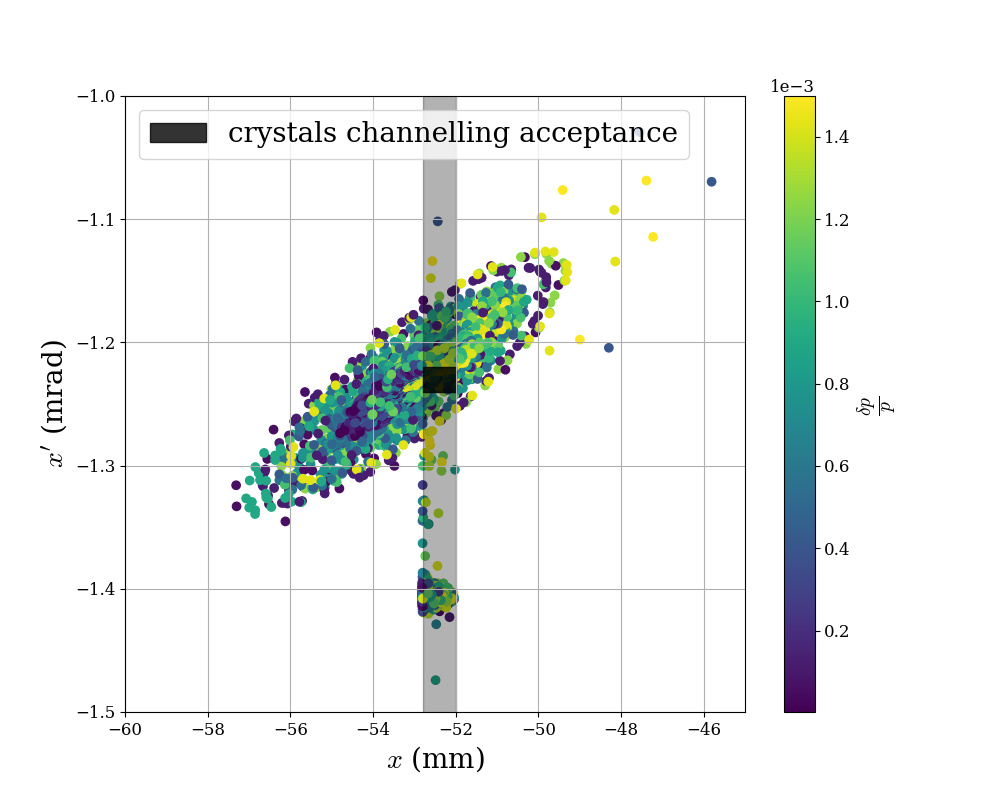

In [162]:
import matplotlib.pyplot as plt

# Set global plot style
plt.rcParams.update({
    'font.size': 12,          # Font size like a paper
    'font.family': 'serif',    # Use serif font (LaTeX style)
    'axes.labelsize': 12,      # Axis labels
    'axes.titlesize': 12,      # Title size
    'legend.fontsize': 12,     # Legend font size
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
})

row_TECA_entry = tw_lss2_df.loc['TECA.entry']
row_TECA_exit = tw_lss2_df.loc['TECA.exit']

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)

for turn in range(monitor_tun_number):
    sc = ax.scatter(
        row_TECA_exit['monitors'].x[:, turn] * 1e3,  # Use data for x at the current turn
        row_TECA_exit['monitors'].px[:, turn] * 1e3,  # Use data for px at the current turn
        c=particles_init._delta,  # Use dpp values from particles_init._delta
        cmap='viridis'
    )
cbar = plt.colorbar(sc, label=r"$\frac{\delta p}{p}$ ")
cbar.ax.yaxis.label.set_size(20)

#ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')

ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.8, label='crystals channelling acceptance')
ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], -100, +100, color='k', alpha=0.3)

#ax.plot([], [], 'k.', label='Particles at TECA entry')
#ax.plot([], [], 'b.', label='Particles after TECA')
#ax.set_title("Phase space at TECA over the last 100 turns", fontsize=20)
ax.legend(fontsize=20, loc = 'upper left')
ax.grid(True)

ax.set_xlim(-60, -45)
ax.set_ylim(-1.5, -1)

ax.set_xlabel(r"$x$ (mm)")
ax.set_ylabel(r"$x'$ (mrad)")

plt.savefig('teca_phase_space.png', bbox_inches='tight')

# Time evolution at TECA location

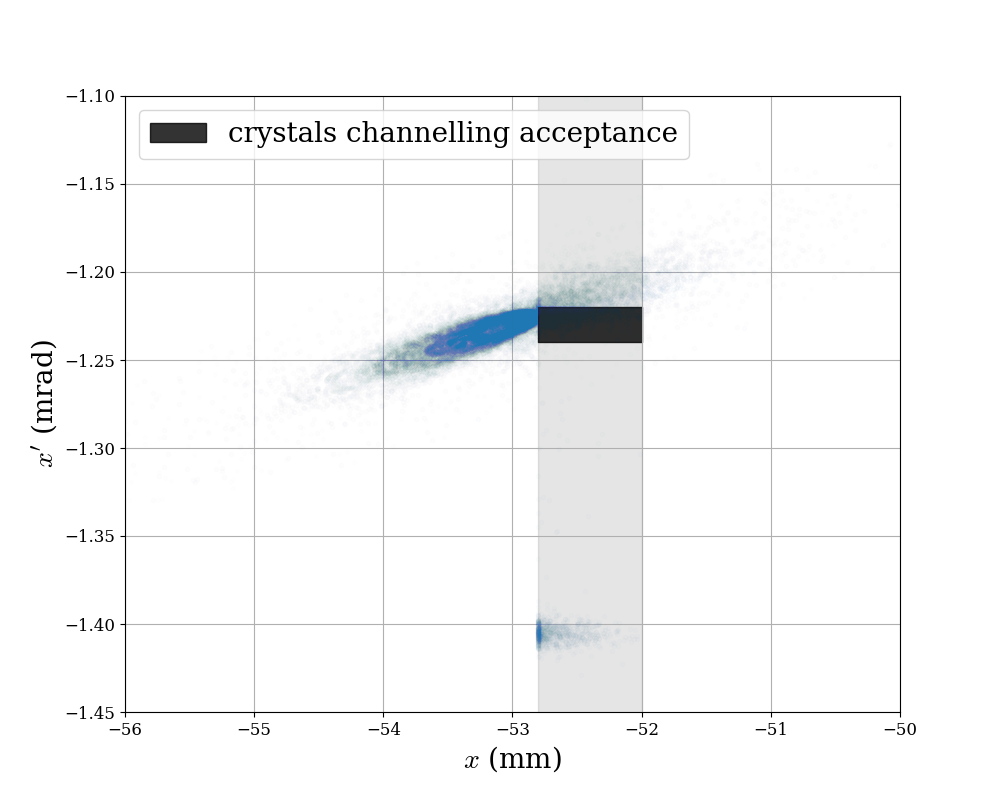

In [ ]:
import matplotlib.pyplot as plt

# Set global plot style
plt.rcParams.update({
    'font.size': 12,          # Font size like a paper
    'font.family': 'serif',    # Use serif font (LaTeX style)
    'axes.labelsize': 12,      # Axis labels
    'axes.titlesize': 12,      # Title size
    'legend.fontsize': 12,     # Legend font size
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
})

row_TECA_entry = tw_lss2_df.loc['TECA.entry']
row_TECA_exit = tw_lss2_df.loc['TECA.exit']

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)

for turn in range(monitor_tun_number):
    alpha_val = (turn + 1) / num_turns  # alpha increases from 0 to 1
    ax.plot(
        row_TECA_exit['monitors'].x[:, turn] * 1e3,
        row_TECA_exit['monitors'].px[:, turn] * 1e3,
        '.', 
        color='C0',
        alpha=alpha_val
    ) 

#ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')

ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.8, label='crystals channelling acceptance')
ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], -100, +100, color='k', alpha=0.1)

#ax.plot([], [], 'k.', label='Particles at TECA entry')
#ax.plot([], [], 'b.', label='Particles after TECA')
#ax.set_title("Phase space at TECA over the last 100 turns", fontsize=20)
ax.legend(fontsize=20)
ax.grid(True)

ax.set_xlim(-55, -51)
ax.set_ylim(-1.45, -1.1)

ax.set_xlabel(r"$x$ (mm)")
ax.set_ylabel(r"$x'$ (mrad)")

plt.savefig('teca_phase_space.png', bbox_inches='tight')

# Phase space at TPST

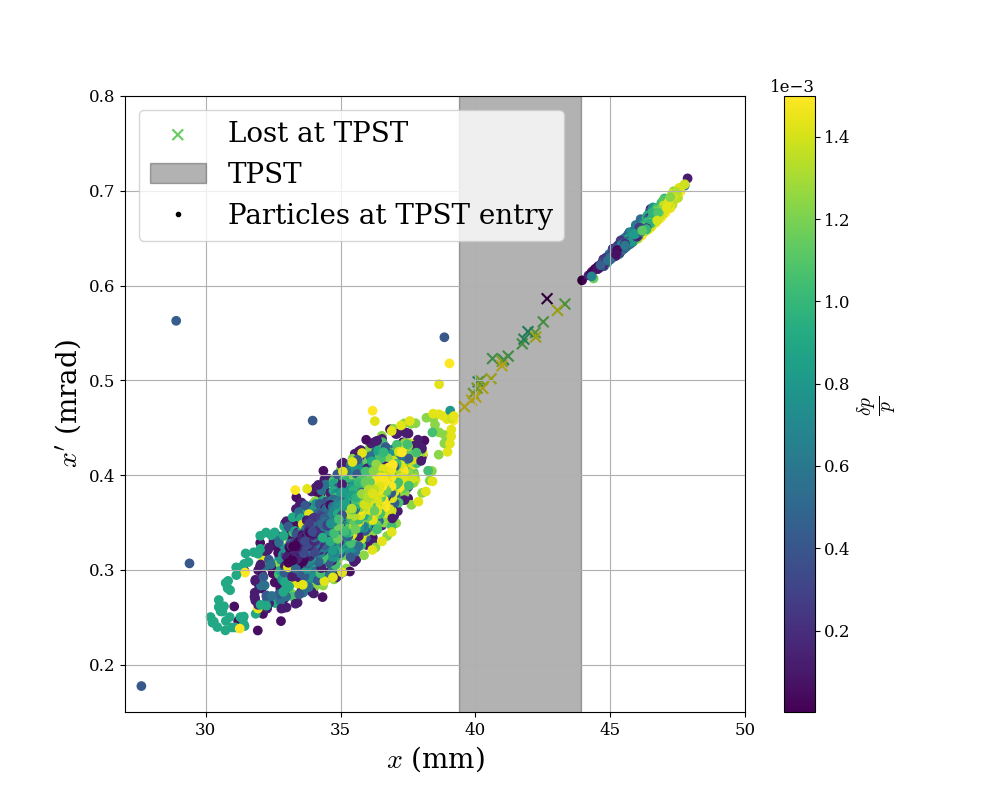

In [164]:
import matplotlib.pyplot as plt

# Set global plot style
plt.rcParams.update({
    'font.size': 12,          # Font size like a paper
    'font.family': 'serif',    # Use serif font (LaTeX style)
    'axes.labelsize': 12,      # Axis labels
    'axes.titlesize': 12,      # Title size
    'legend.fontsize': 12,     # Legend font size
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
})

row_TPST_entry = tw_lss2_df.loc['tpst.21760_entry']

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

#ax.plot(row_TPST_entry['monitors'].x[:, :] * 1e3, row_TPST_entry['monitors'].px[:, :] * 1e3, 'k.', alpha=0.5)
for turn in range(monitor_tun_number):
    sc = ax.scatter(
        row_TPST_entry['monitors'].x[:, turn] * 1e3,  # Use data for x at the current turn
        row_TPST_entry['monitors'].px[:, turn] * 1e3,  # Use data for px at the current turn
        c=particles_init._delta,  # Use dpp values from particles_init._delta
        cmap='viridis'
    )
#plt.colorbar(sc, label=r"$\frac{\delta p}{p}$ ")
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)
cbar = plt.colorbar(sc, label=r"$\frac{\delta p}{p}$ ")
cbar.ax.yaxis.label.set_size(20)

# Plot the particles lost at tpst.21760_entry.sep
if lost_at_tpst:
    ax.scatter(
        [particles.x[idx] * 1e3 for idx in lost_at_tpst],    # x in mm
        [particles.px[idx] * 1e3 for idx in lost_at_tpst],   # px in mrad
        c=[particles.delta[idx] for idx in lost_at_tpst],    # dpp for color
        cmap='viridis',
        marker='x',
        s=60,
        label='Lost at TPST'
    )

# Plot the particles lost at mst.21794.sep
if lost_at_mst:
    ax.scatter(
        [particles.x[idx] * 1e3 for idx in lost_at_mst],    # x in mm
        [particles.px[idx] * 1e3 for idx in lost_at_mst],   # px in mrad
        c=[particles.delta[idx] for idx in lost_at_mst],    # dpp for color
        cmap='viridis',
        marker='x',
        s=60,
        label='Lost at TPST'
    )

#ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')
element_name = 'tpst.21760_entry.sep'
x = line[element_name].interaction_process.blade_position
thickness = line[element_name].interaction_process.thickness
ax.fill_between([x*1e3, x*1e3 + thickness*1e3],-1, 1, color='k', alpha=0.3, label='TPST')

ax.plot([], [], 'k.', label='Particles at TPST entry')

#ax.set_title("Phase space at TECA over the last 100 turns", fontsize=20)
ax.legend(fontsize=20)
ax.grid(True)

ax.set_xlim(27, 50)
ax.set_ylim(0.15, 0.8)
ax.set_xlabel(r"$x$ (mm)")
ax.set_ylabel(r"$x'$ (mrad)")

plt.savefig('tpst_phase_space.png', bbox_inches='tight')

# Phase space at the TCSM

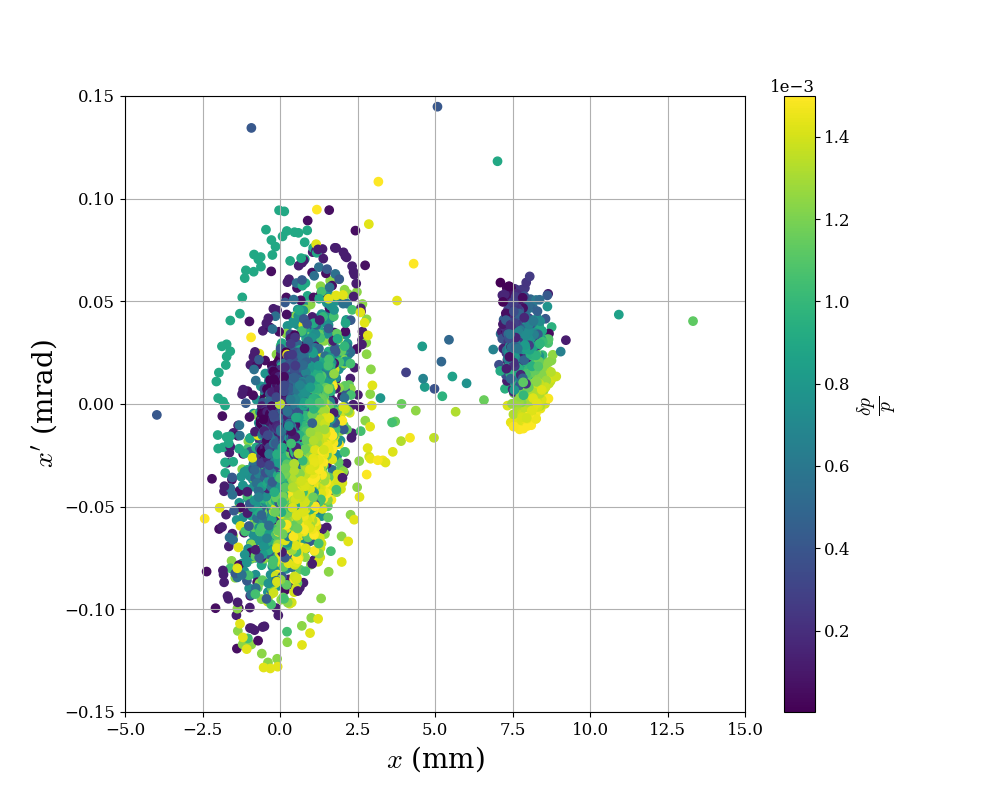

In [165]:
import matplotlib.pyplot as plt

# Set global plot style
plt.rcParams.update({
    'font.size': 12,          # Font size like a paper
    'font.family': 'serif',    # Use serif font (LaTeX style)
    'axes.labelsize': 12,      # Axis labels
    'axes.titlesize': 12,      # Title size
    'legend.fontsize': 12,     # Legend font size
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
})

row_TCSM = tw_lss2_df.loc['tcsm.51932.']

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)

for turn in range(monitor_tun_number):
    sc = ax.scatter(
        row_TCSM['monitors'].x[:, turn] * 1e3,  # Use data for x at the current turn
        row_TCSM['monitors'].px[:, turn] * 1e3,  # Use data for px at the current turn
        c=particles_init._delta,  # Use dpp values from particles_init._delta
        cmap='viridis'
    )
cbar = plt.colorbar(sc, label=r"$\frac{\delta p}{p}$ ")
cbar.ax.yaxis.label.set_size(20)

# You can add acceptance/geometry overlays here if needed

#ax.legend(fontsize=20)
ax.grid(True)

ax.set_xlim(-5, 15)
ax.set_ylim(-0.15, 0.15)

ax.set_xlabel(r"$x$ (mm)")
ax.set_ylabel(r"$x'$ (mrad)")

plt.savefig('tcsm_phase_space.png', bbox_inches='tight')


